# 截图 → TikHub → ASR → 总结 → Flashcard：逐步测速

这个 Notebook 调用**真实生产接口**一次，避免重复下载和重复 ASR；后端在同一次请求中记录每个阶段的独立耗时。后续单元格分别返回 OCR、TikHub 搜索、完整转写、截图时刻定位、局部 Flashcard 和全片总结数据。

默认测试图：仓库根目录 `image3.jpg`。完整视频第一次 ASR 可能需要数分钟；有平台字幕或缓存时会明显更快。

In [24]:
from pathlib import Path
from urllib import request, error, parse
from IPython.display import Image, JSON, display
import base64
import json
import os
import platform
import re
import select
import subprocess
import time

def find_repo_root():
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'backend' / 'src' / 'flow' / 'index.js').exists():
            return candidate
    raise FileNotFoundError('没有找到 AdventureX-2026 仓库根目录')

ROOT = find_repo_root()
IMAGE_PATH = ROOT / 'image3.jpg'
API_BASE = 'http://127.0.0.1:5173'
SOURCE_URL = ''  # 可填准确链接以跳过 TikHub 搜索，单独测试提取/ASR
PUBLIC_BASE_URL = os.environ.get('SHIBEI_PUBLIC_BASE_URL', '')  # 无字幕云端 ASR 时填写公网 HTTPS 后端地址
AUTO_PUBLIC_TUNNEL = True  # 本地无公网地址时，自动用 localhost.run 映射 5173
REQUEST_TIMEOUT_SECONDS = 15 * 60
assert IMAGE_PATH.exists(), f'测试图片不存在：{IMAGE_PATH}'

def ensure_apple_vision_ocr():
    if platform.system() != 'Darwin':
        return None
    source = ROOT / 'backend/src/flow/ocr.swift'
    binary = ROOT / '.runtime/apple-vision-ocr'
    binary.parent.mkdir(parents=True, exist_ok=True)
    if not binary.exists() or binary.stat().st_mtime < source.stat().st_mtime:
        print('首次准备 Apple Vision OCR（编译时间不计入 OCR 耗时）...')
        subprocess.run(['swiftc', str(source), '-o', str(binary)], check=True)
    return binary

APPLE_VISION_BINARY = ensure_apple_vision_ocr()
print('repo:', ROOT)
print('image:', IMAGE_PATH)
print('API:', API_BASE)
print('Apple Vision OCR:', APPLE_VISION_BINARY or '当前系统不可用')
print('public media URL:', PUBLIC_BASE_URL or '尚未设置，将在运行前尝试自动建立临时隧道')

repo: /Users/liqingsong/Desktop/advx/AdventureX-2026
image: /Users/liqingsong/Desktop/advx/AdventureX-2026/image3.jpg
API: http://127.0.0.1:5173
Apple Vision OCR: /Users/liqingsong/Desktop/advx/AdventureX-2026/.runtime/apple-vision-ocr
public media URL: 尚未设置，将在运行前尝试自动建立临时隧道


## 0. 启动并检查后端

如果下面检查失败，请在终端执行：

```bash
cd /Users/liqingsong/Desktop/advx/AdventureX-2026/backend
npm run dev
```

对于**没有平台字幕**的视频，Qwen Filetrans 必须能访问临时音频。部署环境请配置 `SHIBEI_PUBLIC_BASE_URL=https://你的后端域名`。本地测试也可以填写一个映射到 5173 端口的 HTTPS 隧道地址到上面的 `PUBLIC_BASE_URL`。

HTTP: 200
service: recallo-api
TikHub enabled: True


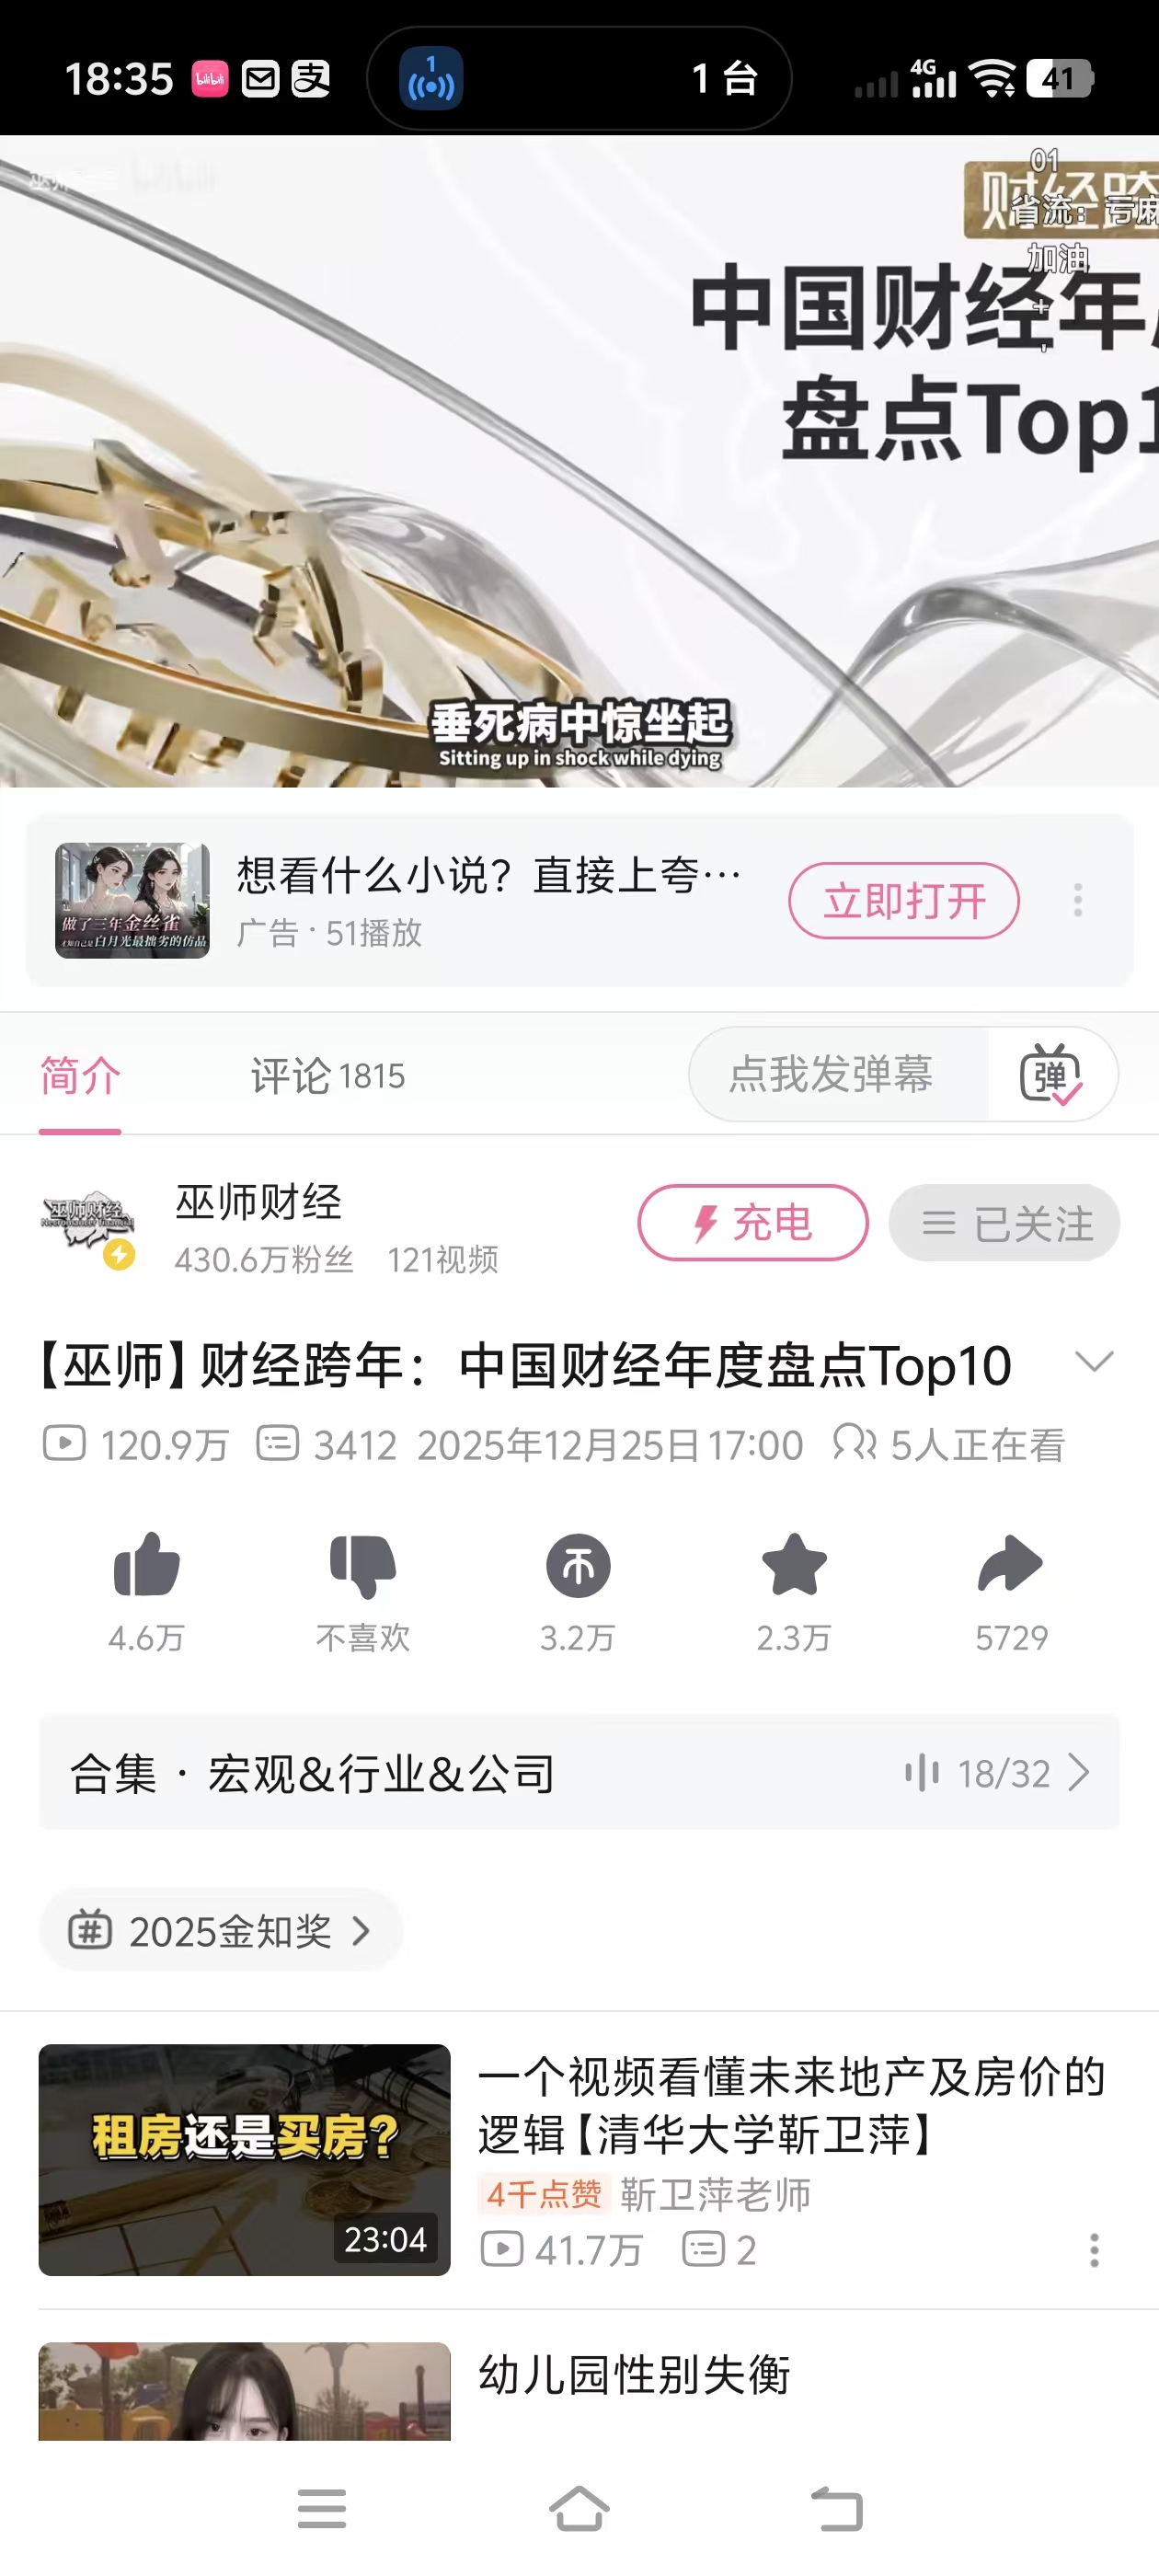

自动隧道失败： 临时 HTTPS 隧道启动失败：et a permission denied error check the faq for how to connect with a key or
create a free tunnel without a key at [http://localhost:3000/docs/faq#generating-an-ssh-key].

To explore using localhost.run visit the documentation site:
https://localhost.run/docs/


** your connection id is 24e2376c-df10-4ae8-88a9-8f6dbbbe4e15, please mention it if you send me a message about an issue. **

authenticated as anonymous user

有字幕视频仍可继续；无字幕视频请手动配置 PUBLIC_BASE_URL。


In [25]:
def get_json(url, timeout=10):
    with request.urlopen(url, timeout=timeout) as response:
        return response.status, json.loads(response.read().decode('utf-8'))

backend_process = None
try:
    health_status, health = get_json(f'{API_BASE}/api/health')
except Exception:
    print('本地后端未运行，正在自动启动...')
    backend_process = subprocess.Popen(
        ['npm', 'run', 'dev'], cwd=ROOT / 'backend',
        stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT
    )
    for _ in range(30):
        try:
            health_status, health = get_json(f'{API_BASE}/api/health', timeout=2)
            break
        except Exception:
            time.sleep(1)
    else:
        raise RuntimeError('本地后端启动失败，请在 backend 目录手动运行 npm run dev')
print('HTTP:', health_status)
print('service:', health.get('service'))
print('TikHub enabled:', health.get('capabilities', {}).get('sources', {}).get('sourceTypes', {}).get('video_link', {}).get('platforms', {}).get('douyin', {}).get('provider') == 'tikhub')
display(Image(filename=str(IMAGE_PATH), width=360))

tunnel_process = None
def start_localhost_run_tunnel(timeout_seconds=25):
    global tunnel_process
    command = [
        'ssh', '-o', 'StrictHostKeyChecking=no', '-o', 'ServerAliveInterval=30',
        '-o', 'ExitOnForwardFailure=yes', '-R', '80:localhost:5173',
        'nokey@localhost.run'
    ]
    tunnel_process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    deadline = time.time() + timeout_seconds
    output = []
    while time.time() < deadline:
        ready, _, _ = select.select([tunnel_process.stdout], [], [], 1)
        if ready:
            line = tunnel_process.stdout.readline()
            output.append(line)
            match = re.search(r'https://[a-z0-9-]+\.lhr\.life', line, re.I)
            if match:
                return match.group(0)
        if tunnel_process.poll() is not None:
            break
    raise RuntimeError('临时 HTTPS 隧道启动失败：' + ''.join(output)[-500:])

if not PUBLIC_BASE_URL and AUTO_PUBLIC_TUNNEL:
    try:
        PUBLIC_BASE_URL = start_localhost_run_tunnel()
        print('temporary public URL:', PUBLIC_BASE_URL)
        public_status, _ = get_json(f'{PUBLIC_BASE_URL}/api/health', timeout=15)
        print('public health HTTP:', public_status)
    except Exception as exc:
        print('自动隧道失败：', exc)
        print('有字幕视频仍可继续；无字幕视频请手动配置 PUBLIC_BASE_URL。')

## 1. 执行一次完整生产链路

该单元格只执行一次昂贵操作。`includeDetails=True` 会返回完整 OCR 行、搜索候选、带时间戳转写和文本块；App 默认不会请求这些调试详情。

In [26]:
def post_flow(image_path, source_url='', public_base_url=''):
    mime = 'image/png' if image_path.suffix.lower() == '.png' else 'image/jpeg'
    image_base64 = base64.b64encode(image_path.read_bytes()).decode('ascii')
    payload = {
        'imageBase64': f'data:{mime};base64,{image_base64}',
        'sourceUrl': source_url.strip(),
        'includeDetails': True,
    }
    headers = {'content-type': 'application/json'}
    if public_base_url:
        public = parse.urlparse(public_base_url)
        headers['x-forwarded-host'] = public.netloc
        headers['x-forwarded-proto'] = public.scheme or 'https'
    body = json.dumps(payload).encode('utf-8')
    req = request.Request(f'{API_BASE}/api/sources/image-flow', data=body, headers=headers, method='POST')
    started = time.perf_counter()
    try:
        with request.urlopen(req, timeout=REQUEST_TIMEOUT_SECONDS) as response:
            status = response.status
            data = json.loads(response.read().decode('utf-8'))
    except error.HTTPError as exc:
        status = exc.code
        data = json.loads(exc.read().decode('utf-8') or '{}')
    elapsed_ms = round((time.perf_counter() - started) * 1000)
    return status, elapsed_ms, data

http_status, client_total_ms, result = post_flow(IMAGE_PATH, SOURCE_URL, PUBLIC_BASE_URL)
print('HTTP:', http_status)
print('flow status:', result.get('status'))
print('client wall time:', client_total_ms, 'ms')
if result.get('status') != 'completed':
    print('error:', json.dumps(result.get('error') or {'message': result.get('message')}, ensure_ascii=False, indent=2))
    print('提示：无字幕视频若报 ASR 配置/访问错误，请设置 PUBLIC_BASE_URL 后重跑本单元格。')
    raise RuntimeError(f"完整链路未完成：{result.get('status')}")

KeyboardInterrupt: 

## 2. OCR：原始行、标题、博主、截图时间

In [ ]:
ocr_data = {
    'timingMs': result.get('timings', {}).get('ocrMs'),
    'provider': result.get('ocr', {}).get('provider'),
    'providerLatencyMs': result.get('ocr', {}).get('latencyMs'),
    'identity': result.get('ocr', {}).get('identity'),
    'raw': result.get('details', {}).get('ocr'),
}
display(JSON(ocr_data, expanded=True))

<IPython.core.display.JSON object>

## 3. TikHub 搜索：查询词、全部候选、严格匹配结果

In [ ]:
search_data = {
    'timingMs': result.get('timings', {}).get('searchMs'),
    'queries': result.get('details', {}).get('searchQueries'),
    'providerResponse': result.get('search'),
    'selectedLink': result.get('link'),
}
display(JSON(search_data, expanded=True))

<IPython.core.display.JSON object>

## 4. 内容提取 / 字幕 / ASR：完整带时间戳数据

In [ ]:
source_details = result.get('details', {}).get('source', {})
transcript_segments = source_details.get('transcriptSegments', [])
source_data = {
    'timingMs': result.get('timings', {}).get('sourceExtractionMs'),
    'source': result.get('source'),
    'extractionMeta': source_details.get('extractionMeta'),
    'transcriptSegmentCount': len(transcript_segments),
    'overviewBlockCount': len(source_details.get('overviewBlocks', [])),
    'overviewTextLength': len(source_details.get('overviewText', '')),
    'first20TranscriptSegments': transcript_segments[:20],
}
display(JSON(source_data, expanded=True))
print('完整数据变量：source_details、transcript_segments')

<IPython.core.display.JSON object>

完整数据变量：source_details、transcript_segments


## 5. 截图时刻定位：附近时间窗口与原文

In [ ]:
focus_data = {
    'focus': result.get('source', {}).get('focus'),
    'focusedRawText': source_details.get('rawText'),
    'focusedBlocks': source_details.get('blocks'),
}
display(JSON(focus_data, expanded=True))

<IPython.core.display.JSON object>

## 6. 截图附近总结与 Flashcard：完整模型返回

In [ ]:
review_data = {
    'timingMs': result.get('timings', {}).get('reviewGenerationMs'),
    'review': result.get('review'),
}
display(JSON(review_data, expanded=True))

<IPython.core.display.JSON object>

## 7. 全片总结：摘要与所有知识点

In [ ]:
overview_data = {
    'timingMs': result.get('timings', {}).get('overviewGenerationMs'),
    'videoOverview': result.get('videoOverview'),
    'fullTranscript': source_details.get('overviewText'),
}
display(JSON(overview_data, expanded=True))

<IPython.core.display.JSON object>

## 8. 总耗时表与完整返回数据

In [ ]:
timings = result.get('timings', {})
assert result.get('review', {}).get('summaryCard', {}).get('text'), '截图附近总结为空'
assert result.get('videoOverview', {}).get('summary'), '全片总结为空'
timing_rows = [
    ('图片准备', timings.get('inputPreparationMs')),
    ('OCR', timings.get('ocrMs')),
    ('TikHub 搜索', timings.get('searchMs')),
    ('内容提取/字幕/ASR', timings.get('sourceExtractionMs')),
    ('截图附近总结与卡片', timings.get('reviewGenerationMs')),
    ('全片总结', timings.get('overviewGenerationMs')),
    ('两个总结并行墙钟时间', timings.get('generationWallMs')),
    ('后端总时间', timings.get('totalMs')),
    ('Notebook 客户端总时间', client_total_ms),
]
for name, value in timing_rows:
    seconds = f'{value / 1000:.3f}s' if isinstance(value, (int, float)) else '-'
    print(f'{name:<24} {str(value):>8} ms  {seconds}')

print('\n完整 API 返回保存在变量 result；以下为完整 JSON：')
display(JSON(result, expanded=False))

图片准备                            2 ms  0.002s
OCR                           581 ms  0.581s
TikHub 搜索                    3055 ms  3.055s
内容提取/字幕/ASR                     2 ms  0.002s
截图附近总结与卡片                       2 ms  0.002s
全片总结                         3130 ms  3.130s
两个总结并行墙钟时间                   3129 ms  3.129s
后端总时间                        6770 ms  6.770s
Notebook 客户端总时间              6776 ms  6.776s

完整 API 返回保存在变量 result；以下为完整 JSON：


<IPython.core.display.JSON object>